# Transformer 真实影评情感分类 (IMDb Dataset)
这次我们使用斯坦福真实的 IMDb 影评数据集进行训练。任务：阅读整段影评，预测它的情感极性（正面 / 负面）。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

from loaddata import create_dataloaders, padding_attention_bias
from transformer import PositionEmbed, Encoder_layer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 1. 加载真实的 IMDb 影评数据
data_dir = 'aclImdb'
batch_size = 64
max_length = 128  # 影评比简介长，把 max_length 调大有助于保留更多语义

train_loader, test_loader, dataset = create_dataloaders(
    data_dir=data_dir,
    batch_size=batch_size,
    max_length=max_length
)
vocab_size = dataset.vocab_size
print(f"Vocab size: {vocab_size}")

[OK] train 数据集加载完成:
   总样本数: 25000
   正面样本: 12500
   负面样本: 12500
   词汇表大小: 29128
[OK] test 数据集加载完成:
   总样本数: 25000
   正面样本: 12500
   负面样本: 12500
   词汇表大小: 29128

[split] 数据划分:
   训练集批次数: 391
   测试集批次数: 391
Vocab size: 29128


In [3]:
# 2. 定义分类模型 (Encoder-Only)
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model=256, head_num=4, num_layers=4):
        super().__init__()
        self.embed = PositionEmbed(d_model=d_model, max_seq_len=max_seq_len, vocab_size=vocab_size)
        self.encoders = nn.ModuleList([
            Encoder_layer(d_model=d_model, head_num=head_num, ffn_hidden_dim=d_model * 4)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model // 2, 2)
        )
        
    def forward(self, x, attention_mask=None):
        out = self.embed(x)
        mask = padding_attention_bias(attention_mask) if attention_mask is not None else None
        for encoder in self.encoders:
            out = encoder(out, mask=mask)
        
        # 提取第一个 <CLS> token
        cls_out = out[:, 0, :]
        logits = self.classifier(cls_out)
        return logits

model = SentimentClassifier(
    vocab_size=vocab_size,
    max_seq_len=max_length,
    d_model=256,
    head_num=4,
    num_layers=4
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

In [4]:
# 3. 训练与测试过程
epochs = 50
cost_history = []
val_acc_history = []

print("开始真正的影评情感分类训练...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask=attn_mask)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        cost_history.append(loss.item())
        
    # 验证集测试
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        # 避免验证时显存爆掉，这里我们也可以用 tqdm 包裹一下看验证进度
        for batch in tqdm(test_loader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask=attn_mask)
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    val_acc = correct / total
    val_acc_history.append(val_acc)
    print(f"Epoch {epoch+1} 完成 | 平均训练 Loss: {total_loss/len(train_loader):.4f} | 测试集准确率: {val_acc:.4f}")

开始真正的影评情感分类训练...


Validating: 100%|██████████| 391/391 [00:04<00:00, 82.12it/s] 


Epoch 1 完成 | 平均训练 Loss: 0.6555 | 测试集准确率: 0.6778


Validating: 100%|██████████| 391/391 [00:04<00:00, 81.24it/s]


Epoch 2 完成 | 平均训练 Loss: 0.5581 | 测试集准确率: 0.7509


...

Epoch 48 完成 | 平均训练 Loss: 0.1104 | 测试集准确率: 0.7427


Validating: 100%|██████████| 391/391 [00:04<00:00, 85.40it/s]


Epoch 49 完成 | 平均训练 Loss: 0.1161 | 测试集准确率: 0.7556


Validating: 100%|██████████| 391/391 [00:04<00:00, 84.70it/s]

Epoch 50 完成 | 平均训练 Loss: 0.1137 | 测试集准确率: 0.7588


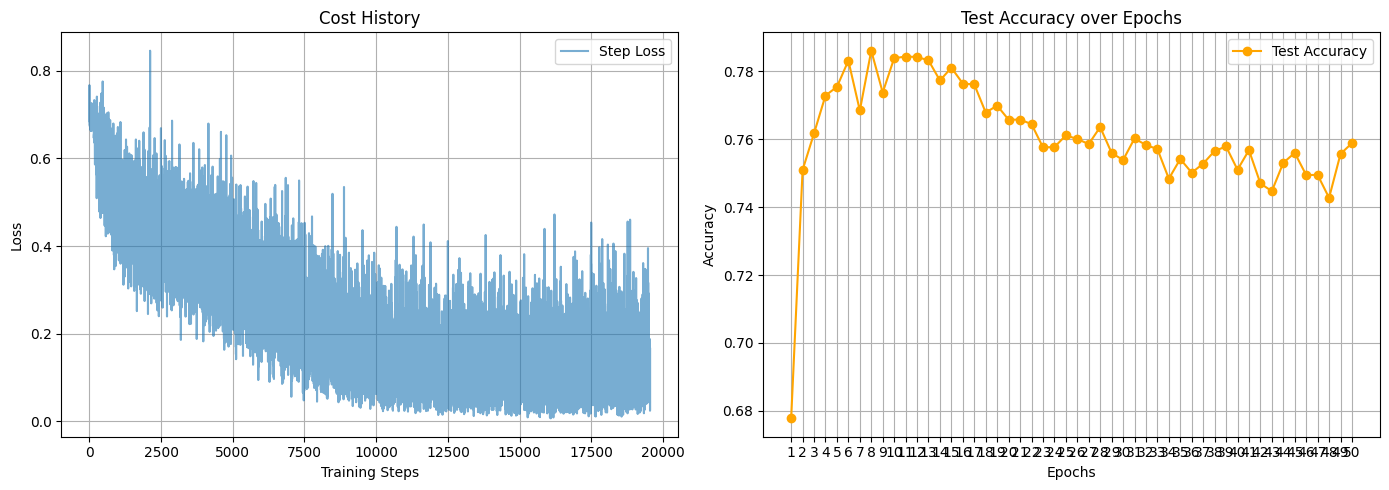

In [5]:
# 4. 绘制结果
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(cost_history, label='Step Loss', alpha=0.6)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Cost History')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_acc_history, label='Test Accuracy', color='orange', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.xticks(range(1, epochs + 1))

plt.tight_layout()
plt.show()